# Entrega de Banco de Dados II - Polymarket

Feito por João Rodrigo Dias Costa

---

**Ideia geral:** o sentimento do mercado no Polymarket em relação a um certo evento político influencia nas apostas de preço futuro de alguma criptomoeda? Caso haja correlação, seria possível acompanhá-la e identificar movimentos em uma aposta que ainda não foram correspondidos na outra, e vice-versa?



## Setup

Reutilizando as configurações iniciais do notebook de exemplo disponibilizado pela Analytica.

In [46]:
import pandas as pd
import numpy as np # usado na parte IV
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import matplotlib.ticker as mticker

def carrega(nome):
    """Lê um CSV exportado do BigQuery, convertendo timestamps (sufixo ' UTC')."""
    df = pd.read_csv(nome)
    for col in df.columns:
        if df[col].dtype == object and df[col].astype(str).str.endswith("UTC").any():
            df[col] = pd.to_datetime(df[col].str.replace(" UTC", "", regex=False))
    return df

## Parte I - Identificando mercados relacionados à política

Nessa primeira etapa, busco identificar mercados de aposta relacionados à política, em especial, os americanos (já que, supostamente, são a maioria na plataforma, tendo em vista que o Polymarket é americano, e também porque o governo dos Estados Unidos possui a maior reserva estatal de criptomoedas).

Vou fazer um filtro usando palavras-chaves que talvez indiquem uma relação política: *election, fed, president, democratic, republican, party, trump, senate, congress*

```sql
-- Q1: qual é o perfil de uma aposta relacionada à política? [custo: 133,74 MB]
SELECT
  market_id,
  question,
  event_title,
  volume,
  created_at,
  end_date,
  closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE REGEXP_CONTAINS(LOWER(question),
  r'election|fed|president|democratic|republican|party|trump|senate|congress')
ORDER BY volume DESC
LIMIT 40;
```

In [47]:
q1 = carrega("dados/q1.csv")
q1.head(10)

,market_id,question,event_title,volume,created_at,end_date,closed
0,253591,Will Donald Trump win the 2024 US Presidential...,Presidential Election Winner 2024,1.531479e+09,2024-01-04 17:33:51.000000 UTC,2024-11-05 12:00:00.000000 UTC,1
1,253597,Will Kamala Harris win the 2024 US Presidentia...,Presidential Election Winner 2024,1.037039e+09,2024-01-04 17:40:17.000000 UTC,2024-11-04 12:00:00.000000 UTC,1
2,511754,Will Donald Trump be inaugurated?,Who will be inaugurated as President?,4.004095e+08,2024-11-01 20:59:58.000000 UTC,2025-01-20 12:00:00.000000 UTC,1
3,512340,Will Nicolae Ciucă win the 2024 Romanian Presi...,(Old) Romania Election,3.265077e+08,2024-11-07 23:53:29.000000 UTC,2024-12-08 12:00:00.000000 UTC,1
4,253642,Will any other Republican Politician win the 2...,Presidential Election Winner 2024,2.416551e+08,2024-01-06 19:52:35.000000 UTC,2024-11-05 00:00:00.000000 UTC,1
5,601697,Fed decreases interest rates by 50+ bps after ...,Fed decision in January?,2.350652e+08,2025-09-17 16:22:35.000000 UTC,2026-01-28 00:00:00.000000 UTC,1
6,601700,Fed increases interest rates by 25+ bps after ...,Fed decision in January?,2.164557e+08,2025-09-17 16:22:39.000000 UTC,2026-01-28 00:00:00.000000 UTC,1
7,654415,Will the Fed increase interest rates by 25+ bp...,Fed decision in March?,1.729721e+08,2025-10-28 20:58:06.000000 UTC,2026-03-18 00:00:00.000000 UTC,1
8,570360,Fed decreases interest rates by 50+ bps after ...,Fed decision in December?,1.615744e+08,2025-07-31 19:28:08.000000 UTC,2025-12-10 00:00:00.000000 UTC,1
9,253609,Will Michelle Obama win the 2024 US Presidenti...,Presidential Election Winner 2024,1.533823e+08,2024-01-05 20:53:17.000000 UTC,2024-11-05 00:00:00.000000 UTC,1


Observa-se que parte das apostas são no estilo "o Candidato X vai ganhar a eleição?" e, outra parte, sobre decisões do FED (Federal Reserve). Como as eleições presidenciais são eventos muito pontuais e dispersos, e, por outro lado, as decisões do FED ocorrem com certa periodicidade, escolhi, nessa análise, tratar dos mercados focados em decisões do FED.

Veja que, para um único event_title "Fed decision in January?" existem duas questions, sendo uma para cada magnitude do aumento ou decréscimo (sendo 1 bps = 0.01%) da taxa de juros (interest rates). Assim, elas podem ser atuar como um indicativo de otimismo do mercado em relação às taxas de juros naquele momento.

## Parte II - Analisando o comportamento de um mercado de decisão do FED

Usaremos os mercados do evento "Fed decision in January?" para o estudo, já que dois deles performaram entre os mercados com maior volume na consulta acima,

Usando uma query similar, dessa vez realizando um filtro, vejamos quais outros tipos de perguntas semelhantes existiram:

```sql
-- Q2a: como foram os mercados relacionados à decisão do FED em Janeiro? [custo: 133,74 MB]
SELECT 
  market_id,
  question,
  event_title,
  volume,
  created_at,
  end_date,
  closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE 
  event_title = 'Fed decision in January?'
ORDER BY volume DESC;
```

In [48]:
q2a = carrega("dados/q2a.csv")
q2a['end_date'] = pd.to_datetime(q2a['end_date'])
q2a[q2a['end_date'].dt.year == 2026]

,market_id,question,event_title,volume,created_at,end_date,closed
0,601697,Fed decreases interest rates by 50+ bps after ...,Fed decision in January?,2.350652e+08,2025-09-17 16:22:35.000000 UTC,2026-01-28 00:00:00+00:00,1
1,601700,Fed increases interest rates by 25+ bps after ...,Fed decision in January?,2.164557e+08,2025-09-17 16:22:39.000000 UTC,2026-01-28 00:00:00+00:00,1
2,601699,No change in Fed interest rates after January ...,Fed decision in January?,1.067671e+08,2025-09-17 16:22:38.000000 UTC,2026-01-28 00:00:00+00:00,1
3,601698,Fed decreases interest rates by 25 bps after J...,Fed decision in January?,1.012115e+08,2025-09-17 16:22:37.000000 UTC,2026-01-28 00:00:00+00:00,1


Assim, vê-se que houveram tanto mercados para um decréscimo alto (< -50bps), para um decréscimo baixo (< -25bps), para nenhuma mudança e para um acréscimo (>= 25bps).

Vejamos na tabela `trades` como as probabilidades de cada um desses cenários evoluíram ao longo do tempo até o `end_date` no dia 28/01/2026:

```sql
-- Q2b: histórico diário de probabilidades para o evento "Fed decision in January?" [custo: 788,31 MB]
SELECT
  market_id,
  TIMESTAMP_TRUNC(trade_timestamp, DAY) AS data,
  AVG(price) AS probabilidade
FROM `even-continuity-441808-j0.polymarket_optimized.trades`
WHERE 
  market_id IN ('601697', '601700', '601699', '601698')
  AND trade_timestamp >= '2025-09-17'
  AND trade_timestamp <= '2026-01-29'
GROUP BY 1, 2
ORDER BY data ASC;
```

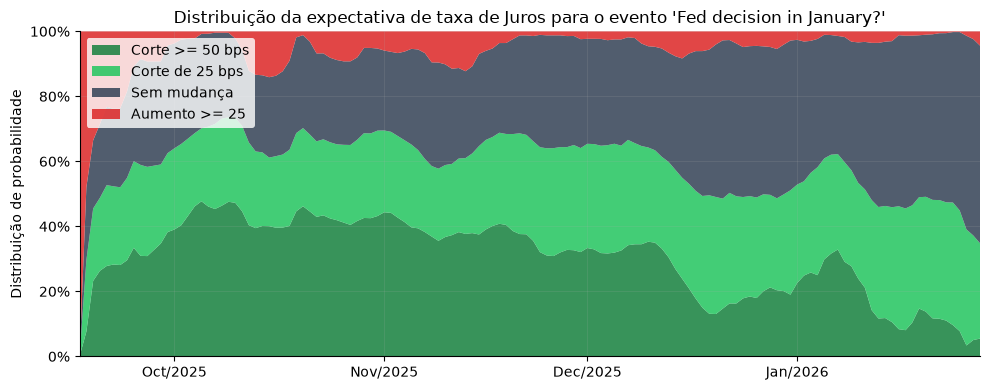

In [49]:
q2b = carrega("dados/q2b.csv")
q2b["data"] = pd.to_datetime(
    q2b["data"].astype(str).str.replace(" UTC", "", regex=False)
)

df_pivot = q2b.pivot(index="data", columns="market_id", values="probabilidade")
df_smooth = df_pivot.rolling(window=7, min_periods=1).mean()

cols_order = [601697, 601698, 601699, 601700]
df_stack = df_smooth[cols_order].fillna(0)
df_stack_norm = df_stack.div(df_stack.sum(axis=1), axis=0)

rotulos = {
    601697: "Corte >= 50 bps",
    601698: "Corte de 25 bps",
    601699: "Sem mudança",
    601700: "Aumento >= 25",
}

cores_mercados = {
    601697: "#15803d",
    601698: "#22c55e",
    601699: "#334155",
    601700: "#dc2626",
}

fig, ax = plt.subplots(figsize=(10, 4))

ax.stackplot(
    df_stack_norm.index,
    [df_stack_norm[c] for c in cols_order],
    labels=[rotulos[c] for c in cols_order],
    colors=[cores_mercados[c] for c in cols_order],
    alpha=0.85,
)

ax.set_ylabel("Distribuição de probabilidade")
ax.set_ylim(0, 1)
ax.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax.legend(loc="upper left", frameon=True, facecolor="white", edgecolor="none")
ax.set_title(
    "Distribuição da expectativa de taxa de Juros para o evento 'Fed decision in January?'"
)
ax.grid(True, alpha=0.15)

ax.set_xlim(df_stack_norm.index.min(), df_stack_norm.index.max())
ax.xaxis.set_major_locator(mdates.MonthLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b/%Y"))

fig.autofmt_xdate(rotation=0, ha="center")
plt.tight_layout()
plt.show()

## Parte III - Identificando mercados de criptomoedas

Vamos utilizar uma query semelhante a da Parte I para identificar os mercados de apostas relacionados à criptomoedas que possuem maior volume:

```sql
-- Q3: qual é o perfil de uma aposta de criptomoedas? [custo: 133,74 MB]
SELECT
  market_id,
  question,
  event_title,
  volume,
  created_at,
  end_date,
  closed
FROM `even-continuity-441808-j0.polymarket_optimized.markets`
WHERE REGEXP_CONTAINS(LOWER(question),
  r'cripto|currency|bitcoin|ethereum|solana|stellar|blockchain|monero|polkadot|btc|eth|sol')
ORDER BY volume DESC
LIMIT 40;
```

In [50]:
q3 = carrega("dados/q3.csv")
q3.head(10)

,market_id,question,event_title,volume,created_at,end_date,closed
0,563368,Will Satoshi move any Bitcoin in 2025?,Will Satoshi move any Bitcoin by ___?,4.418079e+07,2025-07-14 15:33:12.000000 UTC,2025-12-31 00:00:00.000000 UTC,1
1,516861,"Will Bitcoin reach $1,000,000 by December 31, ...",What price will Bitcoin hit in 2025?,3.139461e+07,2024-12-30 20:41:14.000000 UTC,2025-12-31 12:00:00.000000 UTC,1
2,1303355,"Will Bitcoin reach $150,000 in February?",What price will Bitcoin hit in February?,2.882922e+07,2026-01-31 02:13:34.000000 UTC,2026-03-01 05:00:00.000000 UTC,1
3,512600,Will Bitcoin hit $100k in November?,Will Bitcoin hit $100k in November?,2.858743e+07,2024-11-08 22:55:15.000000 UTC,2024-11-30 12:00:00.000000 UTC,1
4,1082748,"Will Bitcoin reach $150,000 in January?",What price will Bitcoin hit in January?,2.666091e+07,2026-01-01 19:17:42.000000 UTC,2026-02-01 05:00:00.000000 UTC,1
5,1473040,"Will Bitcoin reach $150,000 in March?",What price will Bitcoin hit in March?,2.414935e+07,2026-03-01 05:11:03.000000 UTC,2026-04-01 04:00:00.000000 UTC,1
6,512250,Will Trump create Bitcoin reserve in first 100...,Will Trump create Bitcoin reserve in first 100...,2.332435e+07,2024-11-06 23:05:42.000000 UTC,2025-04-29 12:00:00.000000 UTC,1
7,255229,Will Bitcoin hit $100k in 2024?,Will Bitcoin hit $100k in 2024?,2.280724e+07,2024-03-04 15:54:19.000000 UTC,2024-12-30 12:00:00.000000 UTC,1
8,254432,Ethereum all time high in 2024?,Ethereum all time high in 2024?,1.951018e+07,2024-02-12 21:15:20.000000 UTC,2024-12-30 12:00:00.000000 UTC,1
9,516863,"Will Bitcoin reach $200,000 by December 31, 2025?",What price will Bitcoin hit in 2025?,1.927571e+07,2024-12-30 20:43:40.000000 UTC,2025-12-31 12:00:00.000000 UTC,1


Vemos que os 8 mercados de maior volume no nosso filtro são relacionados ao Bitcoin. Dentre eles, o de maior interesse seria "Will Bitcoin reach $150,000 in January?", já que trata do mesmo período de tempo que o mercado analisado na Parte II. Será ele que usaremos no estudo a seguir.

## Parte IV - Comparando o mercado político e o mercado de criptomoeda selecionados

Vejamos o histórico de probabilidades para o mercado selecionado no mesmo período que os mercados do evento "Fed decision in January?":

```sql
-- Q4a: histórico de probabilidades para o mercado "Will Bitcoin reach $150,000 in January?" [custo: 216,32 MB]
-- Query inspirada no notebook enviado pela Analytica (sem a min e max porque, em testes anteriores, haviam muitos outliers)
SELECT
  trade_date, daily_trade_count,
  ROUND(daily_usd_volume, 0)                  AS volume_usd,
  ROUND(avg_trade_price, 3)                   AS preco_medio,
FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
WHERE market_id = '1082748'
ORDER BY trade_date;
```

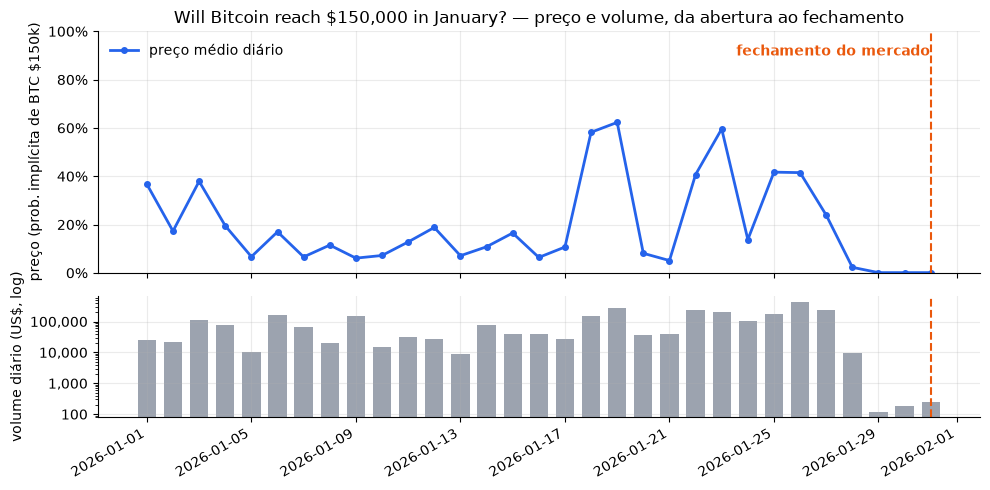

In [51]:
q4a = carrega("dados/q4a.csv")
q4a["trade_date"] = pd.to_datetime(q4a["trade_date"])

FECHAMENTO_MERCADO = pd.Timestamp("2026-01-31")

q4a = q4a[q4a["trade_date"] <= FECHAMENTO_MERCADO]

fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(10, 5),
    sharex=True,
    gridspec_kw={"height_ratios": [2, 1]},
)

# preco médio: linha azul
ax1.plot(
    q4a["trade_date"],
    q4a["preco_medio"],
    color="#2563eb",
    lw=2,
    marker="o",
    ms=4,
    label="preço médio diário",
)

ax1.axvline(FECHAMENTO_MERCADO, color="#ea580c", ls="--", lw=1.5)
ax1.annotate(
    "fechamento do mercado",
    xy=(FECHAMENTO_MERCADO, 0.9),
    xytext=(-140, 0),
    textcoords="offset points",
    color="#ea580c",
    fontweight="bold",
)
ax1.set_ylabel("preço (prob. implícita de BTC $150k)")
ax1.set_ylim(0, 1)
ax1.yaxis.set_major_formatter(mticker.PercentFormatter(1.0))
ax1.legend(loc="upper left", frameon=False)
ax1.set_title(
    "Will Bitcoin reach $150,000 in January? — preço e volume, da abertura ao fechamento"
)

# volume: barras em escala log
ax2.bar(q4a["trade_date"], q4a["volume_usd"], color="#9ca3af", width=0.7)
ax2.set_yscale("log")
ax2.set_ylabel("volume diário (US$, log)")
ax2.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:,.0f}"))
ax2.axvline(FECHAMENTO_MERCADO, color="#ea580c", ls="--", lw=1.5)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

Com isso, podemos comparar ambos os mercados.

Para isso, identificaremos os dias em que houveram maior distanciamento do comportamento de um mercado em relação ao dia anterior, e comparar com a movimentação do mercado que está sendo comparado em paralelo. 

É um modelo simples, que assume uma correlação direta entre ambos os eventos. Apesar dessa relação existir na teoria macroeconômica, o preço do Bitcoin e o mercado de apostas em relação a essa moeda possui (incontáveis) outras variáveis. Assim, essa intuição de encontrar um movimento não correspondido em ambos é um indicativo de que há uma situação interessante a ser investigada, mas não um sinal único de que há uma boa janela de investimento. Para o investimento, seria necessário uma análise mais profunda, e os alertas aqui serviriam apenas como um auxílio.

Faremos três cálculos bem simples: um sobre quanto a expectativa geral de juros do FED subiu ou caiu em relação ao dia anterior, outro sobre quanto o mercado de Bitcoin variou no mesmo dia, e, por fim, o descolamento absoluto entre ambos.

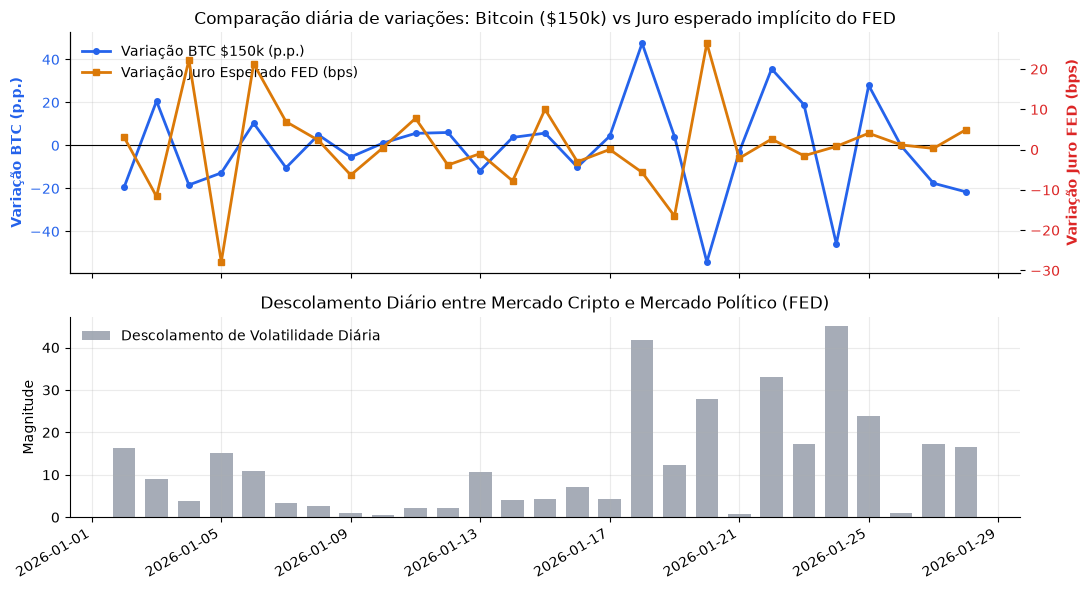

In [ ]:
btc = carrega("dados/q4a.csv")
fed = carrega("dados/q2b.csv")

btc["trade_date"] = pd.to_datetime(btc["trade_date"])
fed["trade_date"] = pd.to_datetime(
    fed["data"].astype(str).str.replace(" UTC", "", regex=False)
).dt.floor("D")

# pesos de cada cenário em bps 
pesos_bps = {
    601697: -50,  # corte >= 50 bps
    601698: -25,  # corte de 25 bps
    601699: 0,    # sem mudança
    601700: 25,   # aumento >= 25 bps
}

# calculando a contribuição esperada de cada cenário
fed["peso"] = fed["market_id"].map(pesos_bps)
fed["juro_contribuicao"] = fed["probabilidade"] * fed["peso"]

# calcula o juro esperado implícito do FED
fed_juro_esperado = (
    fed.groupby("trade_date", as_index=False)["juro_contribuicao"]
    .sum()
    .rename(columns={"juro_contribuicao": "juro_esperado_bps"})
)

# merge com o btc por dia
df = pd.merge(btc, fed_juro_esperado, on="trade_date", how="inner")

# variação diária
df["var_btc"] = df["preco_medio"].diff() * 100
df["var_juro_fed_bps"] = df["juro_esperado_bps"].diff()

# descolamento diário
df["descolamento"] = (df["var_btc"].abs() - df["var_juro_fed_bps"].abs()).abs()


# gráfico ----- inspirado no notebook da analytica, adaptado para dois eixos y
# achei melhor assim pra poder mostrar o juro esperado do FED de forma clara

plt.rcParams.update(
    {
        "figure.figsize": (11, 6),
        "axes.grid": True,
        "grid.alpha": 0.25,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

fig, (ax1, ax2) = plt.subplots(
    2, 1, sharex=True, gridspec_kw={"height_ratios": [1.2, 1]}
)

ax1.plot(
    df["trade_date"],
    df["var_btc"],
    color="#2563eb",
    lw=2,
    marker="o",
    ms=4,
    label="Variação BTC $150k (p.p.)",
)
ax1.axhline(0, color="black", lw=0.8, ls="-")
ax1.set_ylabel("Variação BTC (p.p.)", color="#2563eb", fontweight="bold")
ax1.tick_params(axis="y", labelcolor="#2563eb")

ax1_twin = ax1.twinx()
ax1_twin.plot(
    df["trade_date"],
    df["var_juro_fed_bps"],
    color="#db7908",
    lw=2,
    marker="s",
    ms=4,
    label="Variação Juro Esperado FED (bps)",
)
ax1_twin.set_ylabel(
    "Variação Juro FED (bps)", color="#dc2626", fontweight="bold"
)
ax1_twin.tick_params(axis="y", labelcolor="#dc2626")
ax1_twin.spines["top"].set_visible(False)
ax1_twin.grid(False) 

lines_1, labels_1 = ax1.get_legend_handles_labels()
lines_2, labels_2 = ax1_twin.get_legend_handles_labels()
ax1.legend(
    lines_1 + lines_2, labels_1 + labels_2, loc="upper left", frameon=False
)

ax1.set_title(
    "Comparação diária de variações: Bitcoin ($150k) vs Juro esperado implícito do FED"
)

ax2.bar(
    df["trade_date"],
    df["descolamento"],
    color="#9ca3af",
    width=0.7,
    alpha=0.9,
    label="Descolamento de Volatilidade Diária",
)
ax2.set_ylabel("Magnitude")
ax2.set_title(
    "Descolamento Diário entre Mercado Cripto e Mercado Político (FED)"
)
ax2.legend(loc="upper left", frameon=False)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

## Parte V - Alertas

### Alerta 1

Com base na ideia geral apresentada na Parte I, o alerta, por fim, foi criado com a intenção de avisar quando o descolamento diário entre a variação do mercado de Bitcoin e o mercado do Fed for igual ou superior a um certo número de pontos. Nesse caso, será ativado quando for igual ou superior a 15.

Adaptando o cálculo do Juro Esperado para o FED da Parte IV (que foi feito em Python) e a Q4a do Bitcoin, podemos formar o alerta descrito:

```sql
-- custo do alerta: 11,22 MB

-- definindo os pesos de cada mercado
WITH pesos_do_fed AS (
  SELECT 601697 AS market_id, -50 AS peso_bps UNION ALL
  SELECT 601698 AS market_id, -25 AS peso_bps UNION ALL
  SELECT 601699 AS market_id,   0 AS peso_bps UNION ALL
  SELECT 601700 AS market_id,  25 AS peso_bps
),

-- calcula o juro esperado do FED para cada dia, ponderando pelos cenários (conforme pesos_do_fed)
fed_juro_esperado AS (
  SELECT
    t.trade_date,
    SUM(t.avg_trade_price * p.peso_bps) AS juro_esperado_bps
  FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily` AS t
  INNER JOIN pesos_do_fed AS p
    ON CAST(t.market_id AS INT64) = p.market_id
  WHERE t.trade_date BETWEEN '2026-01-01' AND '2026-01-31'
  GROUP BY t.trade_date
),

-- similar a query Q4a sobre o preco diario do mercado de bitcoin
btc_diario AS (
  SELECT
    trade_date,
    market_id,
    ROUND(avg_trade_price, 4) AS preco_medio_btc,
    ROUND(daily_usd_volume, 2) AS volume_usd
  FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
  WHERE market_id = '1082748'
    AND trade_date BETWEEN '2026-01-01' AND '2026-01-31'
),

-- fazendo o join de ambas e comparando-as
tabela_comparativa AS (
  SELECT
    b.trade_date,
    b.preco_medio_btc,
    b.volume_usd,
    f.juro_esperado_bps,
    ROUND((b.preco_medio_btc - LAG(b.preco_medio_btc) OVER (ORDER BY b.trade_date)) * 100, 2) AS var_btc,
    ROUND(f.juro_esperado_bps - LAG(f.juro_esperado_bps) OVER (ORDER BY f.trade_date), 2) AS var_fed
  FROM btc_diario AS b
  INNER JOIN fed_juro_esperado AS f
    ON b.trade_date = f.trade_date
),

-- calculo final do descolamento
calculo_descolamento AS (
  SELECT
    trade_date,
    preco_medio_btc,
    volume_usd,
    juro_esperado_bps,
    var_btc,
    var_fed,
    ROUND(ABS(ABS(var_btc) - ABS(var_fed)), 2) AS descolamento
  FROM tabela_comparativa
)

-- retorno final; nesse caso, so vai retornar os que estiverem acima de 15
SELECT
  trade_date,
  preco_medio_btc,
  volume_usd,
  var_btc,
  var_fed,
  descolamento,
  'ALERTA: DESCOLAMENTO ATIPICO' AS tipo_alerta
FROM calculo_descolamento
WHERE descolamento >= 15.0
ORDER BY trade_date ASC;
```

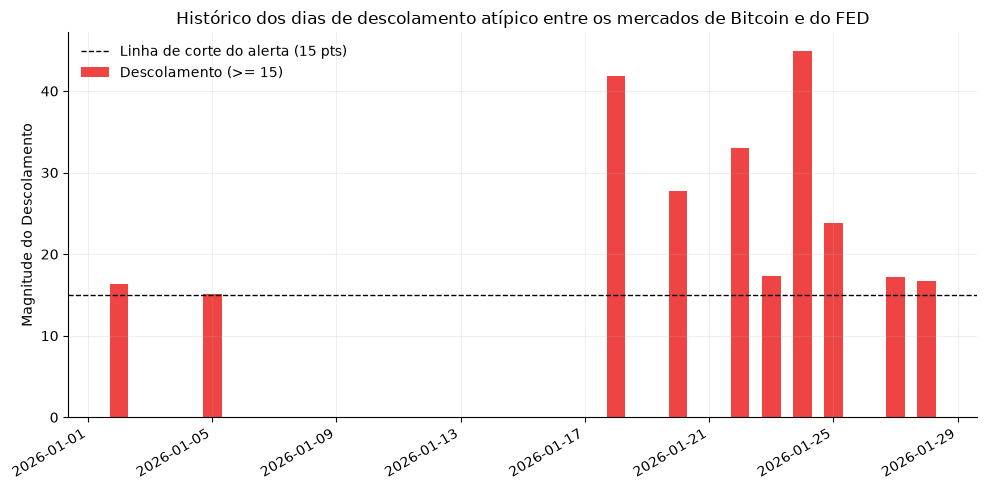

Total de disparos (alerta 1): 10
Disparos assertivos (|var_btc| >= 18 p.p.): 8
Taxa de Assertividade: 80.0%


In [56]:
df_a1 = pd.read_csv("dados/alerta1.csv")
df_a1["trade_date"] = pd.to_datetime(df_a1["trade_date"])

plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.grid": True,
        "grid.alpha": 0.2,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

fig, ax = plt.subplots()

ax.bar(
    df_a1["trade_date"],
    df_a1["descolamento"],
    color="#ef4444",
    width=0.6,
    label="Descolamento (>= 15)",
)

ax.axhline(
    15.0,
    color="black",
    ls="--",
    lw=1,
    label="Linha de corte do alerta (15 pts)",
)

ax.set_ylabel("Magnitude do Descolamento")
ax.set_title("Histórico dos dias de descolamento atípico entre os mercados de Bitcoin e do FED")
ax.legend(loc="upper left", frameon=False)

fig.autofmt_xdate(rotation=30)
plt.tight_layout()
plt.show()

# metodo simples de assertividade: considerar assertivo se |var_btc| >= 18 p.p. no mesmo dia do disparo
disparos_a1 = df_a1[df_a1["descolamento"] >= 15.0].copy()
disparos_a1["assertivo"] = disparos_a1["var_btc"].abs() >= 18.0

total_a1 = len(disparos_a1)
acertos_a1 = disparos_a1["assertivo"].sum()
taxa_a1 = (acertos_a1 / total_a1) * 100 if total_a1 > 0 else 0

print(f"Total de disparos (alerta 1): {total_a1}")
print(f"Disparos assertivos (|var_btc| >= 18 p.p.): {acertos_a1}")
print(f"Taxa de Assertividade: {taxa_a1:.1f}%")

_Obs.: o gráfico não mostra os dias em que não houve o alerta propositalmente, já que a visualização se baseia no csv da consulta SQL já filtrada._

### Alerta 2 (Liquidez)

Criando outro alerta complementar, dessa vez mais simples, a fim de indicar mudanças bruscas no volume diário de negociações do mercado de Bitcoin. O critério selecionado para o disparo foi o volume diário ser maior ou igual a duas vezes a média da última semana (últimos 7 dias). 

```sql
-- custo do alerta: 11,22 MB

-- seleciona e calcula o volume medio dos ultimos 7 dias, juntamente com outras informacoes relevantes
WITH btc_liquidez AS (
  SELECT
    trade_date,
    market_id,
    ROUND(avg_trade_price, 4) AS preco_medio_btc,
    ROUND(daily_usd_volume, 2) AS volume_usd,
    ROUND(
      AVG(daily_usd_volume) OVER (
        ORDER BY trade_date 
        ROWS BETWEEN 7 PRECEDING AND 1 PRECEDING
      ), 2
    ) AS volume_medio_7d
  FROM `even-continuity-441808-j0.polymarket_mart.v_market_daily`
  WHERE market_id = '1082748'
    AND trade_date BETWEEN '2026-01-01' AND '2026-01-31'
)

-- introduz o alerta e os criterios citados
SELECT
  trade_date,
  preco_medio_btc,
  volume_usd,
  volume_medio_7d,
  ROUND(volume_usd / NULLIF(volume_medio_7d, 0), 2) AS multiplicador_volume,
  'ALERTA: PICO DE LIQUIDEZ (>= 2X MEDIA 7D)' AS tipo_alerta
FROM btc_liquidez
WHERE volume_medio_7d > 0
  AND volume_usd >= (2.0 * volume_medio_7d)
ORDER BY trade_date ASC;
```

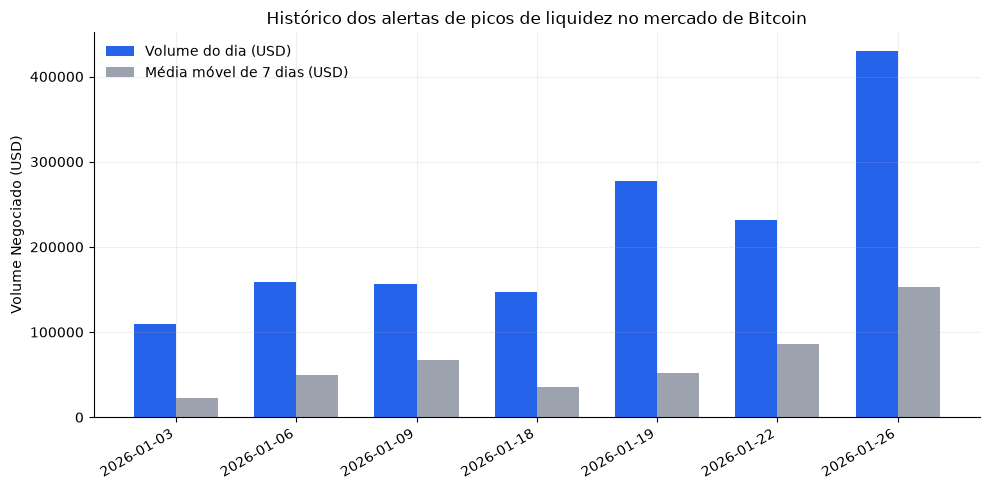

Total de disparos (alerta 2): 7
Disparos assertivos (|var_btc| >= 5 p.p.): 4
Taxa de Assertividade: 57.1%


In [55]:
df_a2 = pd.read_csv("dados/alerta2.csv")
df_a2["trade_date"] = pd.to_datetime(df_a2["trade_date"])

x = np.arange(len(df_a2))
largura = 0.35

plt.rcParams.update(
    {
        "figure.figsize": (10, 5),
        "axes.grid": True,
        "grid.alpha": 0.2,
        "axes.spines.top": False,
        "axes.spines.right": False,
    }
)

fig, ax = plt.subplots()

ax.bar(
    x - largura / 2,
    df_a2["volume_usd"],
    width=largura,
    label="Volume do dia (USD)",
    color="#2563eb",
)
ax.bar(
    x + largura / 2,
    df_a2["volume_medio_7d"],
    width=largura,
    label="Média móvel de 7 dias (USD)",
    color="#9ca3af",
)


ax.set_xticks(x)
ax.set_xticklabels(
    df_a2["trade_date"].dt.strftime("%Y-%m-%d"), rotation=30, ha="right"
)
ax.set_ylabel("Volume Negociado (USD)")
ax.set_title(
    "Histórico dos alertas de picos de liquidez no mercado de Bitcoin"
)
ax.legend(loc="upper left", frameon=False)

plt.tight_layout()
plt.show()

df_a2["var_btc"] = df_a2["preco_medio_btc"].diff() * 100
df_a2["volume_medio_7d"] = (
    df_a2["volume_usd"]
    .rolling(window=7, min_periods=1)
    .mean()
    .shift(1)
    .fillna(df_a2["volume_usd"])
)

# metodo simples de assertividade: considerar assertivo se |var_btc| >= 5 p.p. no mesmo dia do disparo 
total_a2 = len(df_a2)

df_a2["assertivo"] = df_a2["var_btc"].abs() >= 5.0

acertos_a2 = df_a2["assertivo"].sum()
taxa_a2 = (acertos_a2 / total_a2) * 100 if total_a2 > 0 else 0

print(f"Total de disparos (alerta 2): {total_a2}")
print(f"Disparos assertivos (|var_btc| >= 5 p.p.): {acertos_a2}")
print(f"Taxa de Assertividade: {taxa_a2:.1f}%")

### Comentários finais

Gostaria de ter aprofundado mais em métricas de assertividade e técnicas para avaliar a validade dos alertas propostos, mas, devido ao escopo do projeto e o tempo, foquei o relatório ao essencial (identificar mercados interessantes, análisar métricas e compará-las para gerar um alerta útil).